# TODOs:
1. Keep checking log-likelihood calculation.  Do I need different variances?
2. There is a strange factor of 100 floating around.  That also happens to be the number of time steps.  I think I need to be more careful with my use of `dt`.  Hunt this down.
3. Plot predicted time series.
4. Generalize over time steps.
5. Generalize over number of modes.
6. Replace deep dislocation with blocks.
7. Cleaner synthetic data construction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import trange
from scipy.optimize import nnls

# High-resolution plotting
%config InlineBackend.figure_format = "retina"

# Set random seed for reproducibility
np.random.seed(1)

# Helper functions

In [2]:
def ltgt(d):
    if d[0] > d[1]:
        return_string = ">"
    elif d[0] < d[1]:
        return_string = "<"
    elif d[0] == d[1]:
        return_string = "="
    return return_string

# Create synthetic geodetic data from fault model

In [3]:
# Define observation coordinates
n_pts = 50
x_lim = 50
x = np.linspace(-x_lim, x_lim, n_pts)


def get_velocity(slip_rate, x, locking_depth):
    velocity = slip_rate / np.pi * np.arctan(x / locking_depth)
    return velocity


# Define fault patches
n_patches = 2
min_depth = 1e-10
max_depth = 30
locking_depths = np.linspace(min_depth, max_depth, n_patches + 1)

# Velocities
s = 1.0
v_inter = s / np.pi * np.arctan(x / max_depth)
v_mat = np.zeros((n_patches, n_pts))

# Calculate elastic deformation from each patch
for i in range(len(locking_depths) - 1):
    # Velocity kernel calcuation
    v_upper = get_velocity(1, x, locking_depths[i])
    v_lower = get_velocity(1, x, locking_depths[i + 1])
    v = v_lower - v_upper
    v_mat[i, :] = v

# Generate synthetic time series
nt = 100
t_coseismic = 0.5
noise_scale = 0.005
t = np.linspace(0, 1, nt)
time_vec = np.copy(t)
dt = t[1] - t[0]
v0 = 0.5 * np.ones(nt)
v1 = np.zeros(nt)
v2 = np.zeros(nt)

# Coseismic jump on upper fault patch
v_coseismic = 25
coseismic_idx = np.argmin(np.abs(t - t_coseismic))
v1[coseismic_idx] = v_coseismic

# Shallow slow slip event before earthquake
sse_amplitude = 3.0
sse_center = 0.35
sse_width = 0.02
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v1 += v_sse

# Deep slow slip event before earthquake
sse_amplitude = 1.0
sse_center = 0.25
sse_width = 0.03
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v2 += v_sse

# Change interseismic with earthquake
v0[coseismic_idx + 1 : :] = 0.25

# Afterslip on lower fault patch
afterslip_amplitude = 200
# afterslip_amplitude = 0

afterslip_time_scale = 8.0
v2[t > t_coseismic] = afterslip_amplitude * np.exp(
    -afterslip_time_scale * t[t > t_coseismic] - t_coseismic
)

# Assemble linear operator (parameters -> data)
A = np.zeros((n_pts, 3))
A[:, 0] = v_inter
A[:, 1] = -v_mat[0, :]
A[:, 2] = -v_mat[1, :]

H = np.zeros((n_pts, 3))
H[:, 0] = v_inter
H[:, 1] = -v_mat[0, :]
H[:, 2] = -v_mat[1, :]

x_mat = np.zeros((n_pts, nt))
for i in range(nt):
    # x_mat[:, i] = 0 * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])
    x_mat[:, i] = v0[i] * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])

P_true = np.cumsum(x_mat, axis=1) * dt

# Add synthetic noise
P_noise = P_true + noise_scale * np.random.normal(size=P_true.shape)

# Packaging
x0 = np.cumsum(v0)
x1 = np.cumsum(v1)
x2 = np.cumsum(v2)

P_true_noco = np.copy(P_true)
P_noise_noco = np.copy(P_noise)
x1_noco = np.copy(x1)
coseismic_step = x1_noco[coseismic_idx] - x1_noco[coseismic_idx - 1]
x1_noco[coseismic_idx::] -= coseismic_step
x0_noco = np.copy(x0)
x2_noco = np.copy(x2)

for i in range(n_pts):
    # Remove coseismic from noise free observations
    coseismic_step = P_true_noco[i, coseismic_idx] - P_true_noco[i, coseismic_idx - 1]
    P_true_noco[i, coseismic_idx::] -= coseismic_step

    # Remove coseismic from noisy observations
    coseismic_step = P_noise_noco[i, coseismic_idx] - P_noise_noco[i, coseismic_idx - 1]
    P_noise_noco[i, coseismic_idx::] -= coseismic_step


# Scale obsrvations (just because this works well with current gain/variance values???)
model_scale_factor = 100
P_true *= model_scale_factor
P_noise *= model_scale_factor
P_true_noco *= model_scale_factor
P_noise_noco *= model_scale_factor

---
# IMM with MCMC and smoothing (2 states)
---

Running MCMC: 100%|██████████| 500/500 [00:08<00:00, 59.66it/s]


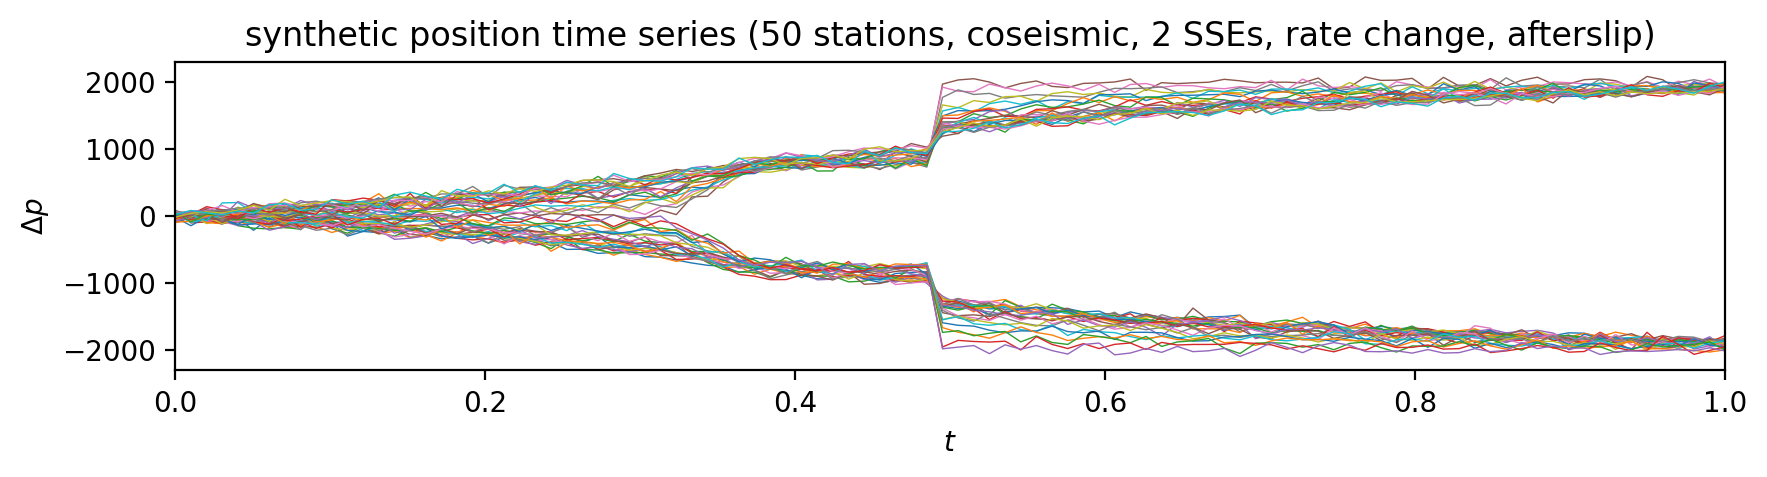

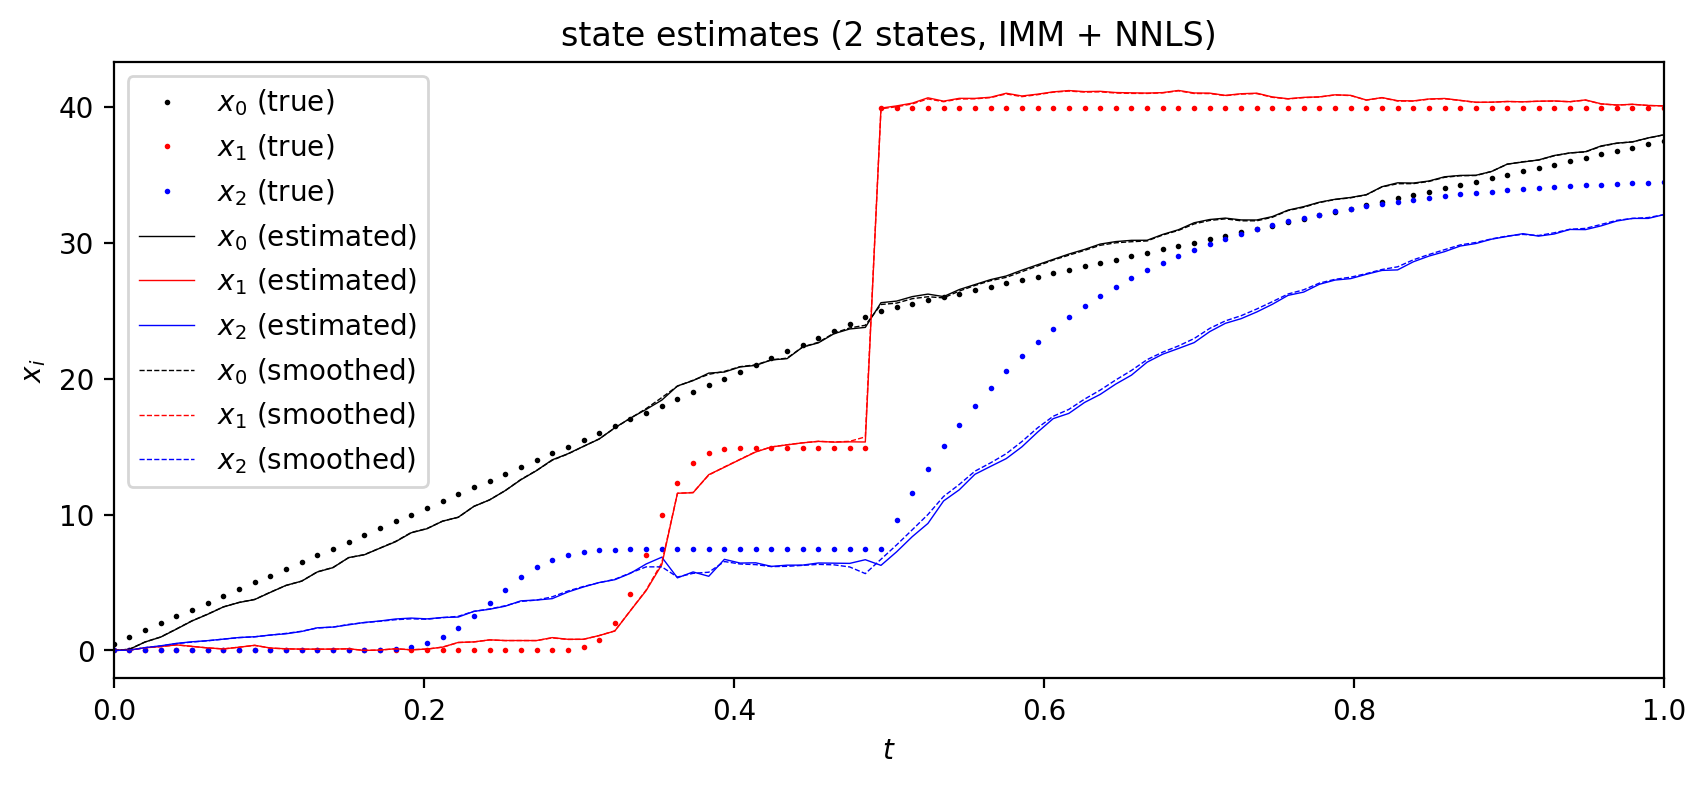

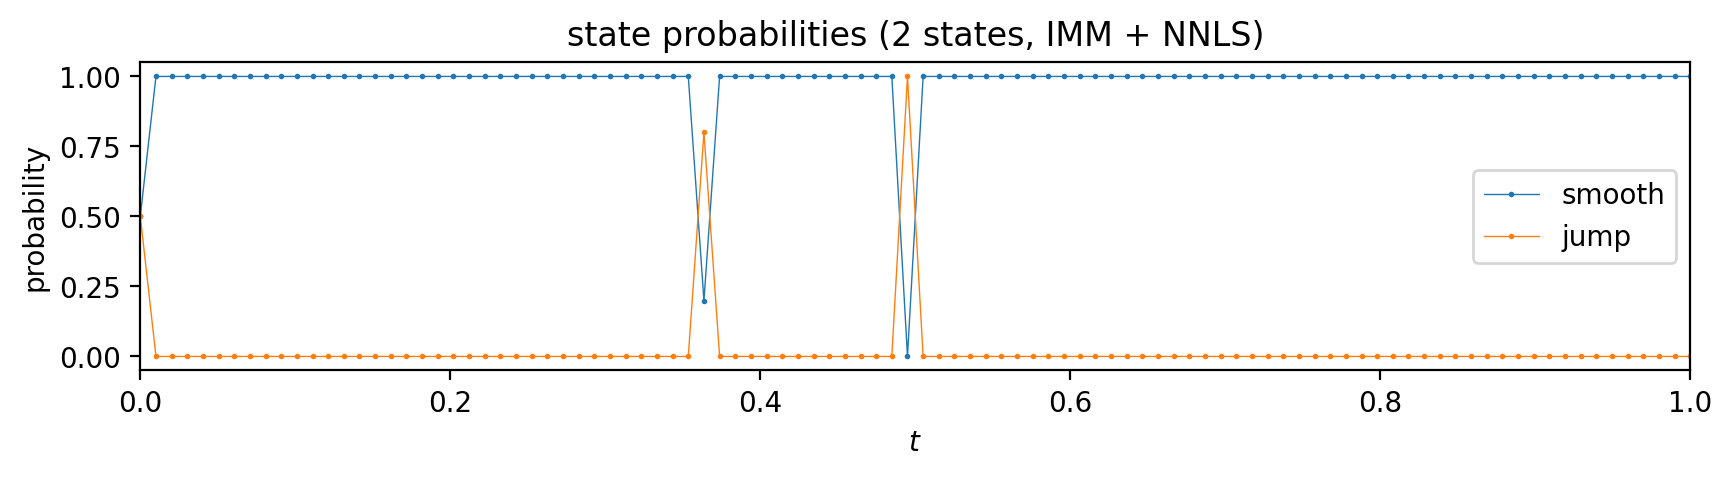

In [4]:
# Parameters for synthetic data
time_steps = 100
num_state_vars = 3  # Number of state variables
num_observations = 50  # Number of observation time series
observation_noise = 1.0
true_state = np.zeros((num_state_vars, time_steps))
observations = np.zeros((num_observations, time_steps))
true_modes = np.zeros(time_steps, dtype=int)
current_level = np.zeros(num_state_vars)
observations = np.copy(P_noise)

# IMM Algorithm Setup
num_models = 2
transition_matrix = np.array([[0.9, 0.1], [0.1, 0.9]])
model_variances = [0.1, 50.0]  # Linear and jump variances

# MCMC Initialization
num_samples = 500
state_estimates = np.zeros((num_models, num_state_vars, time_steps))
covariances = np.zeros((num_models, num_state_vars, num_state_vars, time_steps))
mode_probabilities = np.zeros((num_models, time_steps))
mixed_estimates = np.zeros((num_state_vars, time_steps))
mcmc_modes = np.zeros((num_samples, time_steps), dtype=int)

# Initial values
mode_probabilities[:, 0] = 1 / num_models
current_modes = np.random.choice([0, 1], size=time_steps, p=[0.5, 0.5])

# MCMC Sampling
for sample in trange(num_samples, desc="Running MCMC"):
    for t in range(1, time_steps):
        mixed_states = np.zeros((num_models, num_state_vars))
        mixed_covariances = np.zeros((num_models, num_state_vars, num_state_vars))

        # Mixing step
        for i in range(num_models):
            mixed_probabilities = transition_matrix[:, i] * mode_probabilities[:, t - 1]
            mixed_probabilities /= np.sum(mixed_probabilities)
            mixed_states[i] = np.sum(
                mixed_probabilities[:, None] * state_estimates[:, :, t - 1], axis=0
            )
            mixed_covariances[i] = np.sum(
                mixed_probabilities[:, None, None]
                * (
                    covariances[:, :, :, t - 1]
                    + np.eye(num_state_vars) * model_variances[i]
                ),
                axis=0,
            )

        # Filtering step
        likelihoods = np.zeros(num_models)
        for i in range(num_models):
            # print(i)
            innovation = observations[:, t] - H @ mixed_states[i]
            innovation_covariance = (
                H @ mixed_covariances[i] @ H.T
                + np.eye(num_observations) * observation_noise
            )
            kalman_gain = (
                mixed_covariances[i] @ H.T @ np.linalg.inv(innovation_covariance)
            )

            # Apply Non-Negative Least Squares (NNLS) constraint
            unconstrained_estimate = mixed_states[i] + kalman_gain @ innovation
            nnls_solution, _ = nnls(np.eye(num_state_vars), unconstrained_estimate)

            state_estimates[i, :, t] = nnls_solution
            covariances[i, :, :, t] = (
                np.eye(num_state_vars) - kalman_gain @ H
            ) @ mixed_covariances[i]

            likelihoods[i] = norm.pdf(
                innovation, 0, np.sqrt(np.diag(innovation_covariance))
            ).prod()
            # print(f"{i=}, {likelihoods[i]=}")

        # Sample mode from posterior
        posterior = likelihoods * transition_matrix[current_modes[t - 1], :]
        posterior /= np.sum(posterior)
        current_modes[t] = np.random.choice([0, 1], p=posterior)
        mcmc_modes[sample, t] = current_modes[t]
        mode_probabilities[:, t] = posterior

    # Mixed estimate
    mixed_estimates = np.sum(mode_probabilities[:, None, :] * state_estimates, axis=0)


# TODO: ATTEMPT AT SMOOTHING
smoothed_estimates = np.zeros((num_state_vars, time_steps))
smoothed_estimates[:, -1] = mixed_estimates[
    :, -1
]  # Initialize with final filtered estimate
for t in range(time_steps - 2, -1, -1):
    for i in range(num_models):
        # Smoothing gain
        smoothing_gain = covariances[i, :, :, t] @ np.linalg.inv(
            covariances[i, :, :, t] + np.eye(num_state_vars) * model_variances[i]
        )

        # Smoothed estimate
        smoothed_estimates[:, t] = mixed_estimates[:, t] + smoothing_gain @ (
            smoothed_estimates[:, t + 1] - mixed_estimates[:, t]
        )

        # Apply NNLS constraint to smoothed estimate
        smoothed_estimates[:, t] = np.nan_to_num(smoothed_estimates[:, t])
        nnls_solution, _ = nnls(np.eye(num_state_vars), smoothed_estimates[:, t])
        smoothed_estimates[:, t] = nnls_solution


# Plot results
linewidth = 0.5
markersize = 2.0

plt.figure(figsize=(10, 2))
for i in range(50):
    plt.plot(
        time_vec,
        100 * P_noise[i, :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
# plt.ylim([-250, 250])
plt.title(
    "synthetic position time series (50 stations, coseismic, 2 SSEs, rate change, afterslip)"
)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    time_vec, x0, ".k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x1, ".r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x2, ".b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize
)

plt.plot(
    time_vec,
    mixed_estimates[0, :] / dt / 100,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[1, :] / dt / 100,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[2, :] / dt / 100,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.plot(
    time_vec,
    smoothed_estimates[0, :] / dt / 100,
    "--k",
    label="$x_0$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[1, :] / dt / 100,
    "--r",
    label="$x_1$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[2, :] / dt / 100,
    "--b",
    label="$x_2$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state estimates (2 states, IMM + NNLS)")
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(
    time_vec,
    mode_probabilities[0, :],
    ".-",
    label="smooth",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mode_probabilities[1, :],
    ".-",
    label="jump",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("probability")
plt.xlim([0, 1])
plt.legend()
plt.title("state probabilities (2 states, IMM + NNLS)")
plt.show()

---
# IMM with MCMC and smoothing (5 states)
---

Running MCMC: 100%|██████████| 500/500 [00:20<00:00, 24.35it/s]


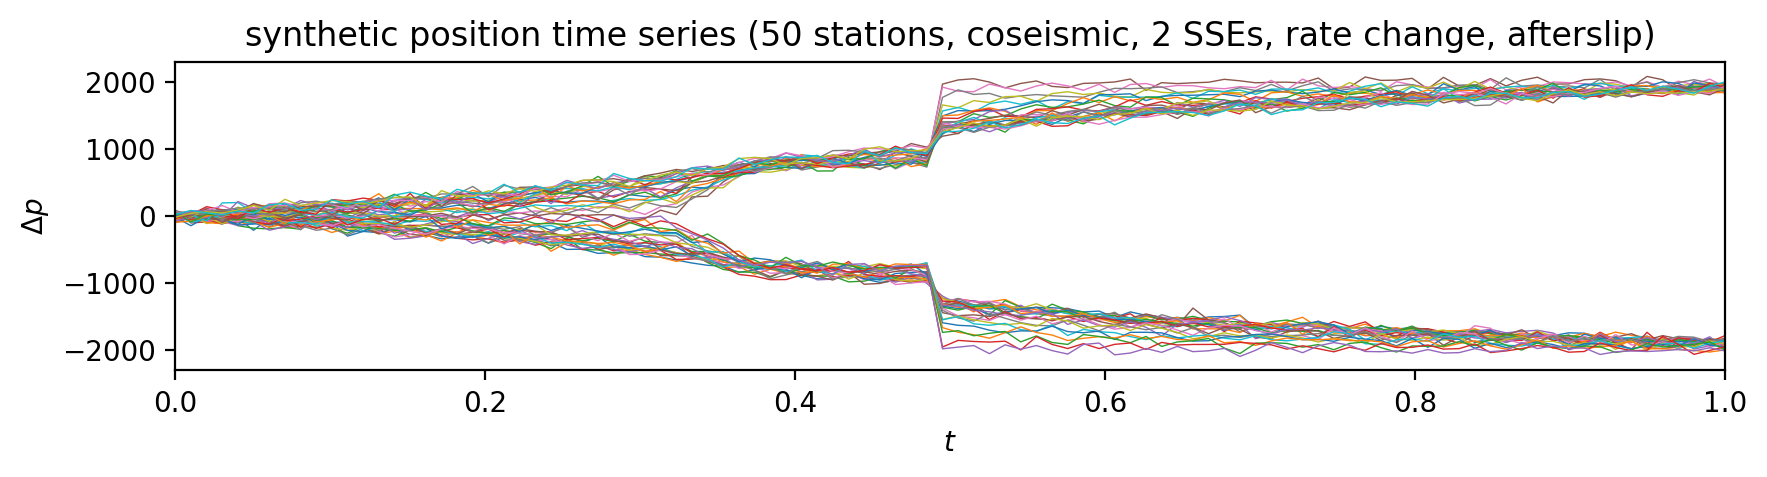

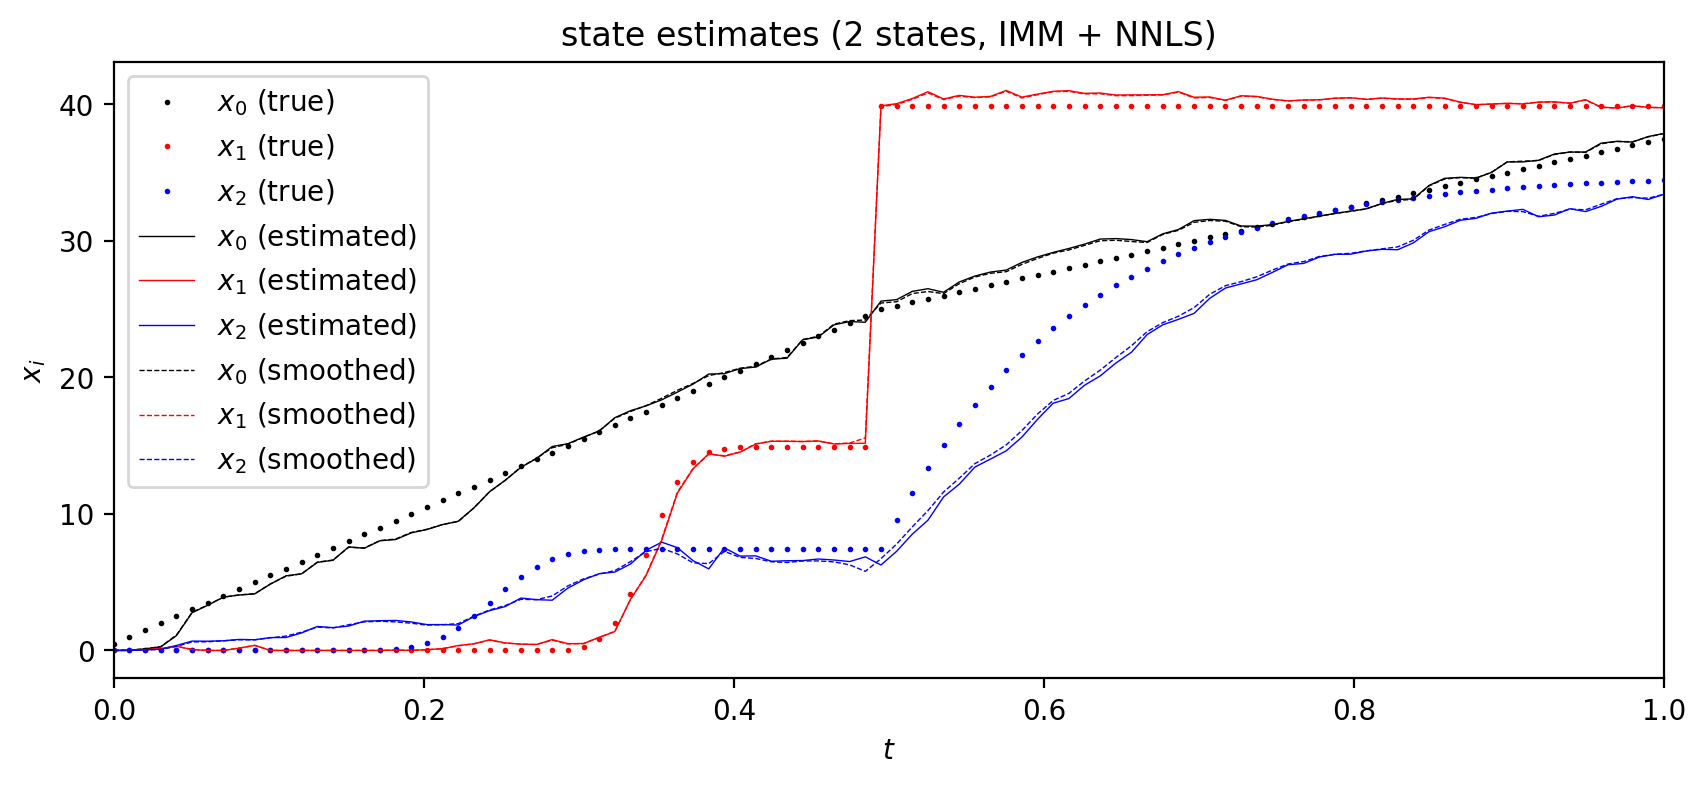

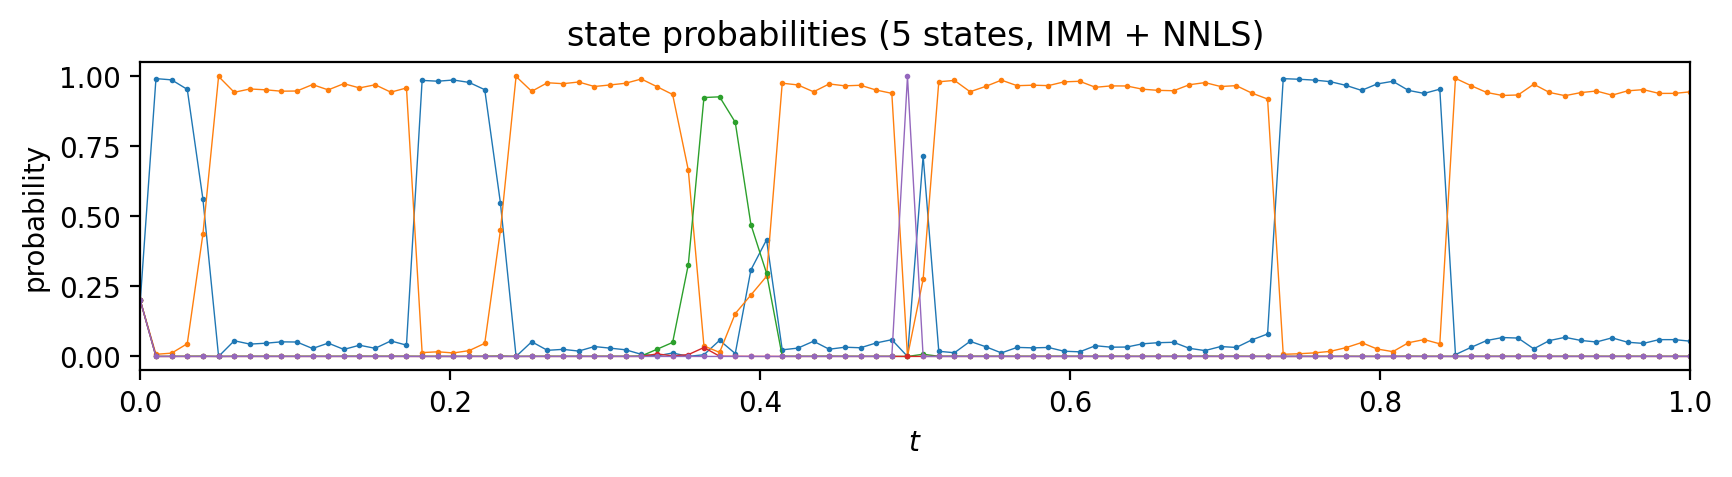

In [5]:
# Parameters for synthetic data
time_steps = 100
num_state_vars = 3  # Number of state variables
num_observations = 50  # Number of observation time series
observation_noise = 1.0
true_state = np.zeros((num_state_vars, time_steps))
observations = np.zeros((num_observations, time_steps))
true_modes = np.zeros(time_steps, dtype=int)
current_level = np.zeros(num_state_vars)
observations = np.copy(P_noise)

# IMM Algorithm Setup
# num_models = 2
# transition_matrix = np.array([[0.9, 0.1], [0.1, 0.9]])
# model_variances = [0.1, 50.0]  # Linear and jump variances

# num_models = 3
# transition_matrix = np.array(
#     [[0.90, 0.05, 0.05], [0.05, 0.90, 0.05], [0.05, 0.05, 0.90]]
# )
# model_variances = [0.5, 5.0, 50.0]  # Linear and jump variances

num_models = 5
transition_matrix = np.array(
    [
        [0.90, 0.02, 0.02, 0.02, 0.02],
        [0.02, 0.90, 0.02, 0.02, 0.02],
        [0.02, 0.02, 0.90, 0.02, 0.02],
        [0.02, 0.02, 0.02, 0.90, 0.02],
        [0.02, 0.02, 0.02, 0.02, 0.90],
    ]
)
model_variances = [0.01, 0.5, 2.5, 5.0, 50.0]
# model_variances = np.logspace(-1.0, 1.0, 5)  # Logarithmic variance distribution


# MCMC Initialization
num_samples = 500
state_estimates = np.zeros((num_models, num_state_vars, time_steps))
covariances = np.zeros((num_models, num_state_vars, num_state_vars, time_steps))
mode_probabilities = np.zeros((num_models, time_steps))
mixed_estimates = np.zeros((num_state_vars, time_steps))
mcmc_modes = np.zeros((num_samples, time_steps), dtype=int)

# Initial values
mode_probabilities[:, 0] = 1 / num_models
current_modes = np.random.choice([0, 1], size=time_steps, p=[0.5, 0.5])

# MCMC Sampling
for sample in trange(num_samples, desc="Running MCMC"):
    for t in range(1, time_steps):
        mixed_states = np.zeros((num_models, num_state_vars))
        mixed_covariances = np.zeros((num_models, num_state_vars, num_state_vars))

        # Mixing step
        for i in range(num_models):
            mixed_probabilities = transition_matrix[:, i] * mode_probabilities[:, t - 1]
            mixed_probabilities /= np.sum(mixed_probabilities)
            mixed_states[i] = np.sum(
                mixed_probabilities[:, None] * state_estimates[:, :, t - 1], axis=0
            )
            mixed_covariances[i] = np.sum(
                mixed_probabilities[:, None, None]
                * (
                    covariances[:, :, :, t - 1]
                    + np.eye(num_state_vars) * model_variances[i]
                ),
                axis=0,
            )

        # Filtering step
        likelihoods = np.zeros(num_models)
        for i in range(num_models):
            # print(i)
            innovation = observations[:, t] - H @ mixed_states[i]
            innovation_covariance = (
                H @ mixed_covariances[i] @ H.T
                + np.eye(num_observations) * observation_noise
            )
            kalman_gain = (
                mixed_covariances[i] @ H.T @ np.linalg.inv(innovation_covariance)
            )

            # Apply Non-Negative Least Squares (NNLS) constraint
            unconstrained_estimate = mixed_states[i] + kalman_gain @ innovation
            nnls_solution, _ = nnls(np.eye(num_state_vars), unconstrained_estimate)

            state_estimates[i, :, t] = nnls_solution
            covariances[i, :, :, t] = (
                np.eye(num_state_vars) - kalman_gain @ H
            ) @ mixed_covariances[i]

            likelihoods[i] = norm.pdf(
                innovation, 0, np.sqrt(np.diag(innovation_covariance))
            ).prod()
            # print(f"{i=}, {likelihoods[i]=}")

        # Sample mode from posterior
        posterior = likelihoods * transition_matrix[current_modes[t - 1], :]
        posterior /= np.sum(posterior)
        # current_modes[t] = np.random.choice([0, 1], p=posterior)
        # TODO: Generalize choice over arbitrary number of states
        current_modes[t] = np.random.choice([0, 1, 2, 3, 4], p=posterior)

        mcmc_modes[sample, t] = current_modes[t]
        mode_probabilities[:, t] = posterior

    # Mixed estimate
    mixed_estimates = np.sum(mode_probabilities[:, None, :] * state_estimates, axis=0)

mcmc_mode_probabilities = np.copy(mode_probabilities)


# TODO: ATTEMPT AT SMOOTHING
smoothed_estimates = np.zeros((num_state_vars, time_steps))
smoothed_estimates[:, -1] = mixed_estimates[
    :, -1
]  # Initialize with final filtered estimate
for t in range(time_steps - 2, -1, -1):
    for i in range(num_models):
        # Smoothing gain
        smoothing_gain = covariances[i, :, :, t] @ np.linalg.inv(
            covariances[i, :, :, t] + np.eye(num_state_vars) * model_variances[i]
        )

        # Smoothed estimate
        smoothed_estimates[:, t] = mixed_estimates[:, t] + smoothing_gain @ (
            smoothed_estimates[:, t + 1] - mixed_estimates[:, t]
        )

        # Apply NNLS constraint to smoothed estimate
        smoothed_estimates[:, t] = np.nan_to_num(smoothed_estimates[:, t])
        nnls_solution, _ = nnls(np.eye(num_state_vars), smoothed_estimates[:, t])
        smoothed_estimates[:, t] = nnls_solution


# Plot results
linewidth = 0.5
markersize = 2.0

plt.figure(figsize=(10, 2))
for i in range(50):
    plt.plot(
        time_vec,
        100 * P_noise[i, :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
# plt.ylim([-250, 250])
plt.title(
    "synthetic position time series (50 stations, coseismic, 2 SSEs, rate change, afterslip)"
)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    time_vec, x0, ".k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x1, ".r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x2, ".b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize
)

plt.plot(
    time_vec,
    mixed_estimates[0, :] / dt / 100,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[1, :] / dt / 100,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[2, :] / dt / 100,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.plot(
    time_vec,
    smoothed_estimates[0, :] / dt / 100,
    "--k",
    label="$x_0$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[1, :] / dt / 100,
    "--r",
    label="$x_1$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[2, :] / dt / 100,
    "--b",
    label="$x_2$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state estimates (2 states, IMM + NNLS)")
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(
    time_vec,
    mode_probabilities[0, :],
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mode_probabilities[1, :],
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mode_probabilities[2, :],
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)

plt.plot(
    time_vec,
    mode_probabilities[3, :],
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)

plt.plot(
    time_vec,
    mode_probabilities[4, :],
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)


plt.xlabel("$t$")
plt.ylabel("probability")
plt.xlim([0, 1])
# plt.legend()
plt.title("state probabilities (5 states, IMM + NNLS)")
plt.show()

# IMM with MAP and smoother 2 states)

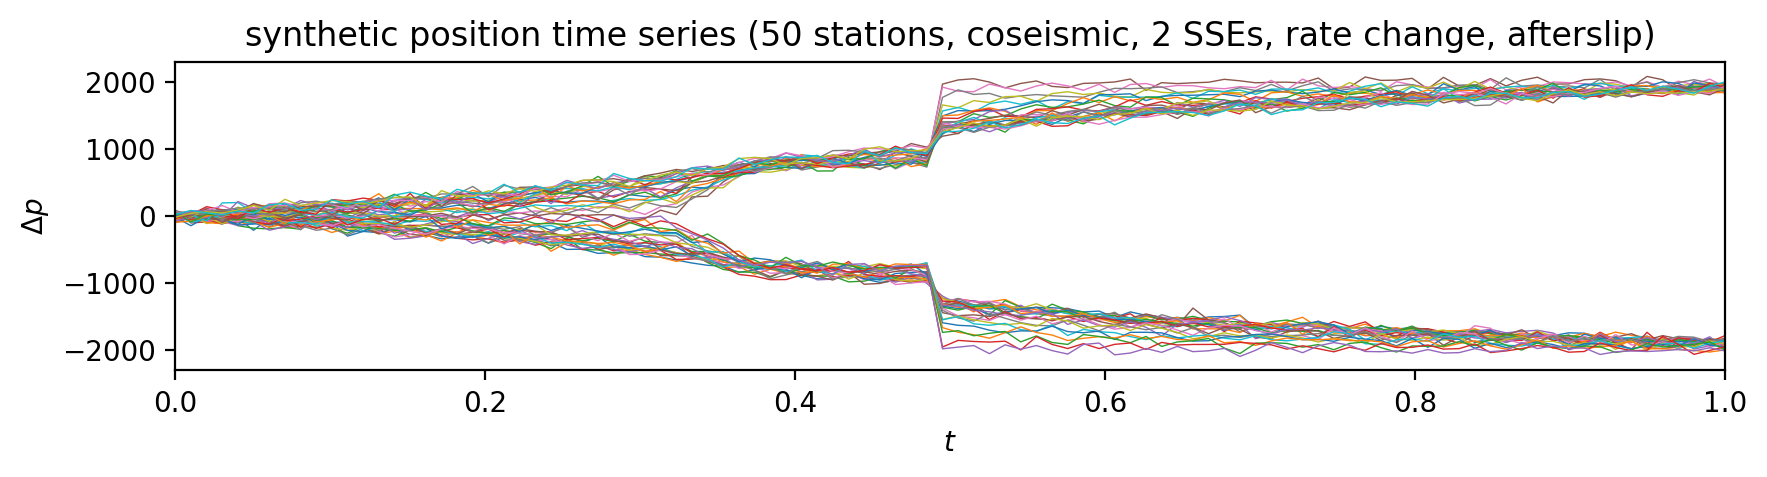

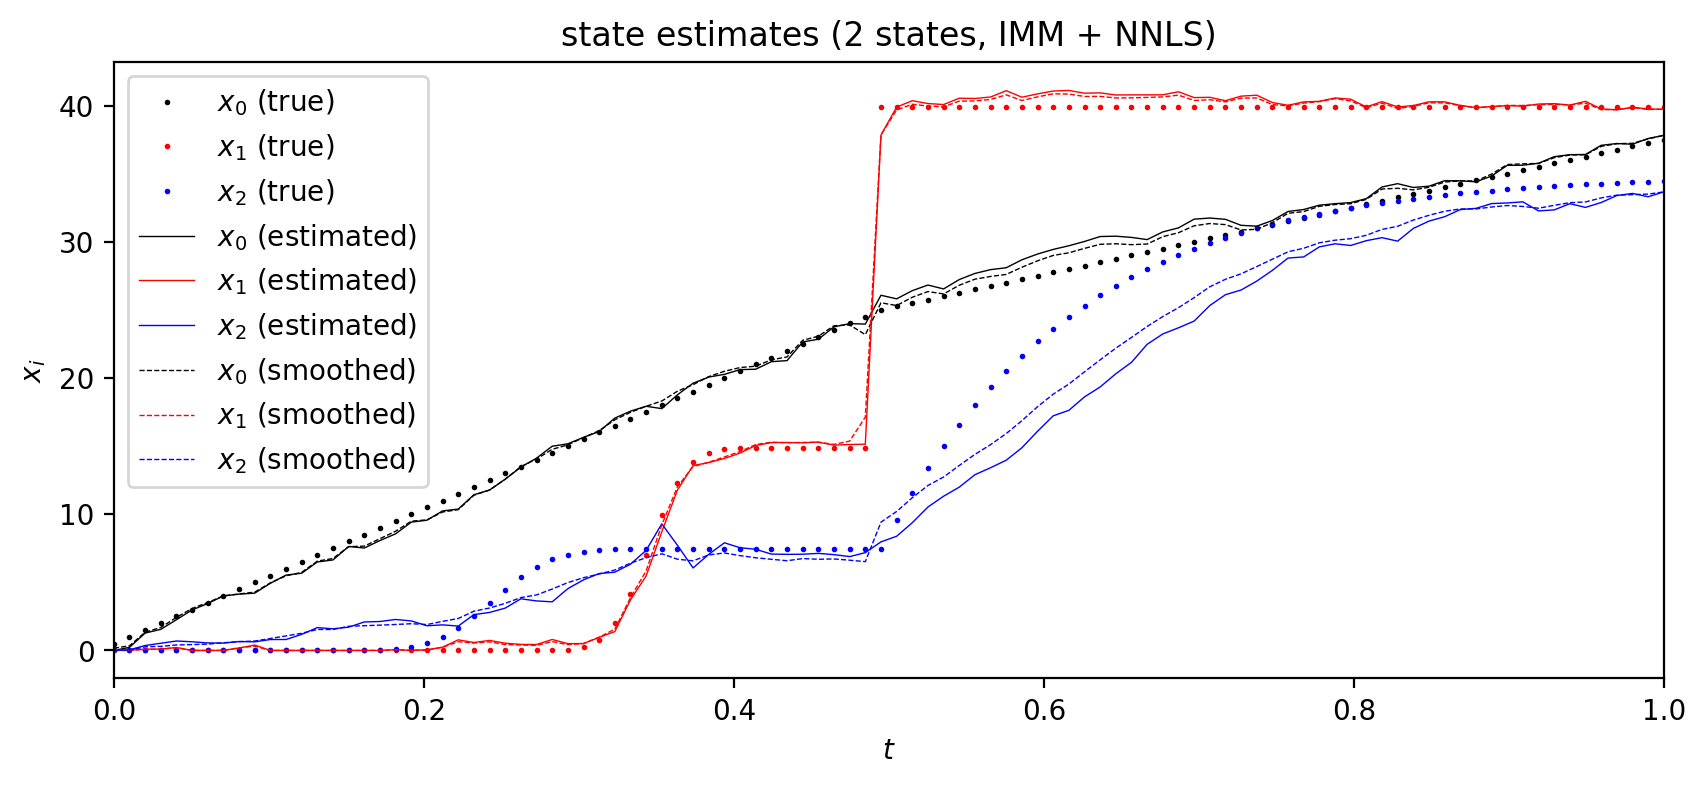

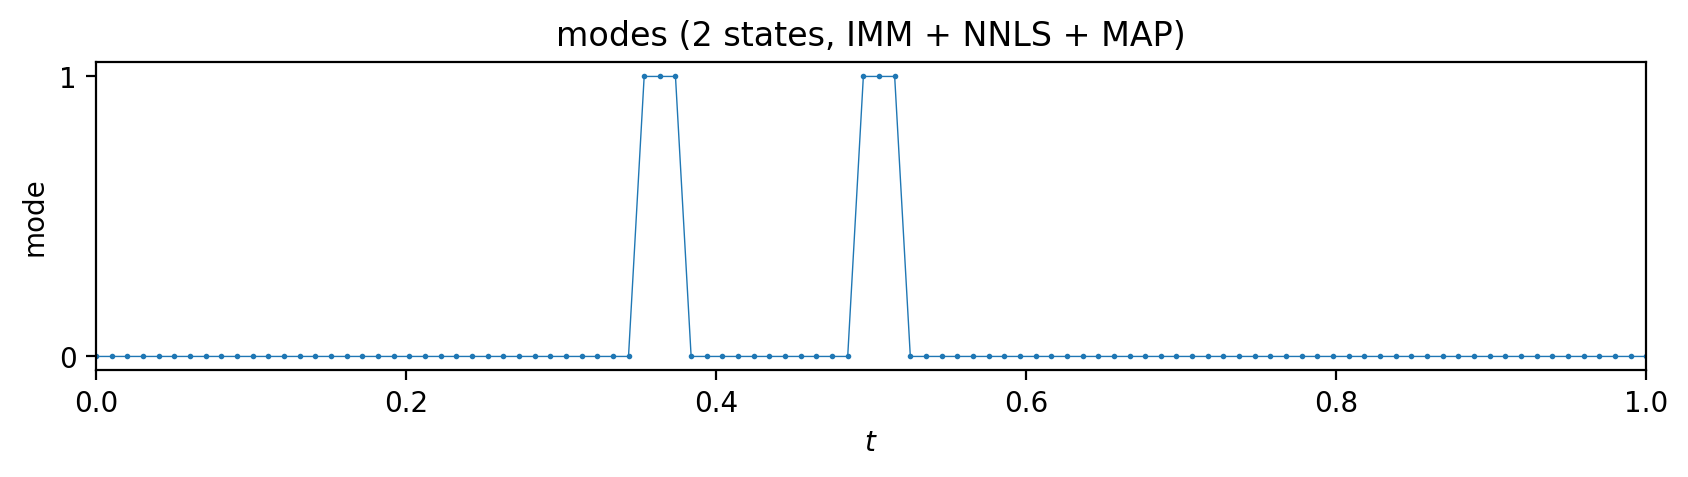

In [6]:
# Parameters for synthetic data
time_steps = 100
num_state_vars = 3  # Number of state variables
num_observations = 50  # Number of observation time series
observation_noise = 1.0

# Generate synthetic data
true_state = np.zeros((num_state_vars, time_steps))
observations = np.zeros((num_observations, time_steps))
true_modes = np.zeros(time_steps, dtype=int)
current_level = np.zeros(num_state_vars)
observations = np.copy(P_noise)

# MAP Algorithm with NNLS Setup
num_models = 2
transition_matrix = np.array([[0.9, 0.1], [0.1, 0.9]])
model_variances = [0.5, 5.0]  # Linear and jump variances

# Initialization
state_estimates = np.zeros((num_models, num_state_vars, time_steps))
covariances = np.zeros((num_models, num_state_vars, num_state_vars, time_steps))
mode_probabilities = np.zeros((num_models, time_steps))
mixed_estimates = np.zeros((num_state_vars, time_steps))
smoothed_estimates = np.zeros((num_state_vars, time_steps))
mode_sequence = np.zeros(time_steps, dtype=int)

# Initial values
mode_probabilities[:, 0] = 1 / num_models
for i in range(num_models):
    covariances[i, :, :, 0] = np.eye(num_state_vars) * model_variances[i]

# Forward Pass (Filtering)
for t in range(1, time_steps):
    likelihoods = np.zeros(num_models)
    for i in range(num_models):
        # Predict step
        if t == 1:
            mixed_state = np.zeros(num_state_vars)
            mixed_covariance = np.eye(num_state_vars) * model_variances[i]
        else:
            mixed_state = state_estimates[i, :, t - 1]
            mixed_covariance = (
                covariances[i, :, :, t - 1]
                + np.eye(num_state_vars) * model_variances[i]
            )

        # Update step
        innovation = observations[:, t] - H @ mixed_state
        innovation_covariance = (
            H @ mixed_covariance @ H.T + np.eye(num_observations) * observation_noise
        )

        # Regularize innovation covariance to avoid singularity
        innovation_covariance += np.eye(num_observations) * 1e-6

        kalman_gain = mixed_covariance @ H.T @ np.linalg.inv(innovation_covariance)

        # Apply Non-Negative Least Squares (NNLS) constraint
        unconstrained_estimate = mixed_state + kalman_gain @ innovation
        unconstrained_estimate = np.nan_to_num(
            unconstrained_estimate
        )  # Ensure no NaNs or Infs
        nnls_solution, _ = nnls(np.eye(num_state_vars), unconstrained_estimate)

        state_estimates[i, :, t] = nnls_solution
        covariances[i, :, :, t] = (
            np.eye(num_state_vars) - kalman_gain @ H
        ) @ mixed_covariance

        likelihoods[i] = norm.pdf(
            innovation, 0, np.sqrt(np.diag(innovation_covariance))
        ).prod()

    # Update mode probabilities using MAP
    transition_probs = transition_matrix[mode_sequence[t - 1]]
    posterior = likelihoods * transition_probs
    current_mode = np.argmax(
        posterior
    )  # Select the mode with maximum a posteriori probability
    mode_sequence[t] = current_mode

    # Use the MAP mode's estimate for the mixed estimate
    mixed_estimates[:, t] = state_estimates[current_mode, :, t]

# Trying smoothing again
smoothed_estimates[:, -1] = mixed_estimates[
    :, -1
]  # Initialize with final filtered estimate
for t in range(time_steps - 2, -1, -1):
    for i in range(num_models):
        # Smoothing gain
        smoothing_gain = covariances[i, :, :, t] @ np.linalg.inv(
            covariances[i, :, :, t] + np.eye(num_state_vars) * model_variances[i]
        )

        # Smoothed estimate
        smoothed_estimates[:, t] = mixed_estimates[:, t] + smoothing_gain @ (
            smoothed_estimates[:, t + 1] - mixed_estimates[:, t]
        )

        # Apply NNLS constraint to smoothed estimate
        smoothed_estimates[:, t] = np.nan_to_num(smoothed_estimates[:, t])
        nnls_solution, _ = nnls(np.eye(num_state_vars), smoothed_estimates[:, t])
        smoothed_estimates[:, t] = nnls_solution

# Plot results
linewidth = 0.5
markersize = 2.0

plt.figure(figsize=(10, 2))
for i in range(50):
    plt.plot(
        time_vec,
        100 * P_noise[i, :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
# plt.ylim([-25, 25])
plt.title(
    "synthetic position time series (50 stations, coseismic, 2 SSEs, rate change, afterslip)"
)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    time_vec, x0, ".k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x1, ".r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x2, ".b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize
)

plt.plot(
    time_vec,
    mixed_estimates[0, :] / dt / 100,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[1, :] / dt / 100,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[2, :] / dt / 100,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.plot(
    time_vec,
    smoothed_estimates[0, :] / dt / 100,
    "--k",
    label="$x_0$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[1, :] / dt / 100,
    "--r",
    label="$x_1$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[2, :] / dt / 100,
    "--b",
    label="$x_2$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state estimates (2 states, IMM + NNLS)")
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(
    time_vec,
    mode_sequence,
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("mode")
plt.xlim([0, 1])
plt.yticks(range(2))
plt.title("modes (2 states, IMM + NNLS + MAP)")
plt.show()

# IMM with MAP and smoother and log-likelihood
- Not sure if this is working
- The variances may need some adjusting for the log case.
- Lots of debugging information is printed


 
t=1
likelihood
likelihoods=array([1.05591970e-23, 3.29490166e-27]), >
transition_probs=array([0.9, 0.1]), >
posterior=array([9.50327734e-24, 3.29490166e-28]), >
 
log-likelihood
log_likelihoods=array([ -7.10581815, -12.56780602]), >
transition_probs=array([0.9, 0.1]), >
posterior_log=array([ -7.21117867, -14.87039112]), >
 
Compare selected index
np.argmax(posterior)=0, np.argmax(posterior_log)=0
 
t=2
likelihood
likelihoods=array([4.57463152e-25, 5.72249534e-28]), >
transition_probs=array([0.9, 0.1]), >
posterior=array([4.11716837e-25, 5.72249534e-29]), >
 
log-likelihood
log_likelihoods=array([-19.65524602, -70.54268642]), >
transition_probs=array([0.9, 0.1]), >
posterior_log=array([-19.76060653, -72.84527151]), >
 
Compare selected index
np.argmax(posterior)=0, np.argmax(posterior_log)=0
 
t=3
likelihood
likelihoods=array([5.80872658e-25, 4.41788704e-28]), >
transition_probs=array([0.9, 0.1]), >
posterior=array([5.22785392e-25, 4.41788704e-29]), >
 
log-likelihood
log_likelihoods=

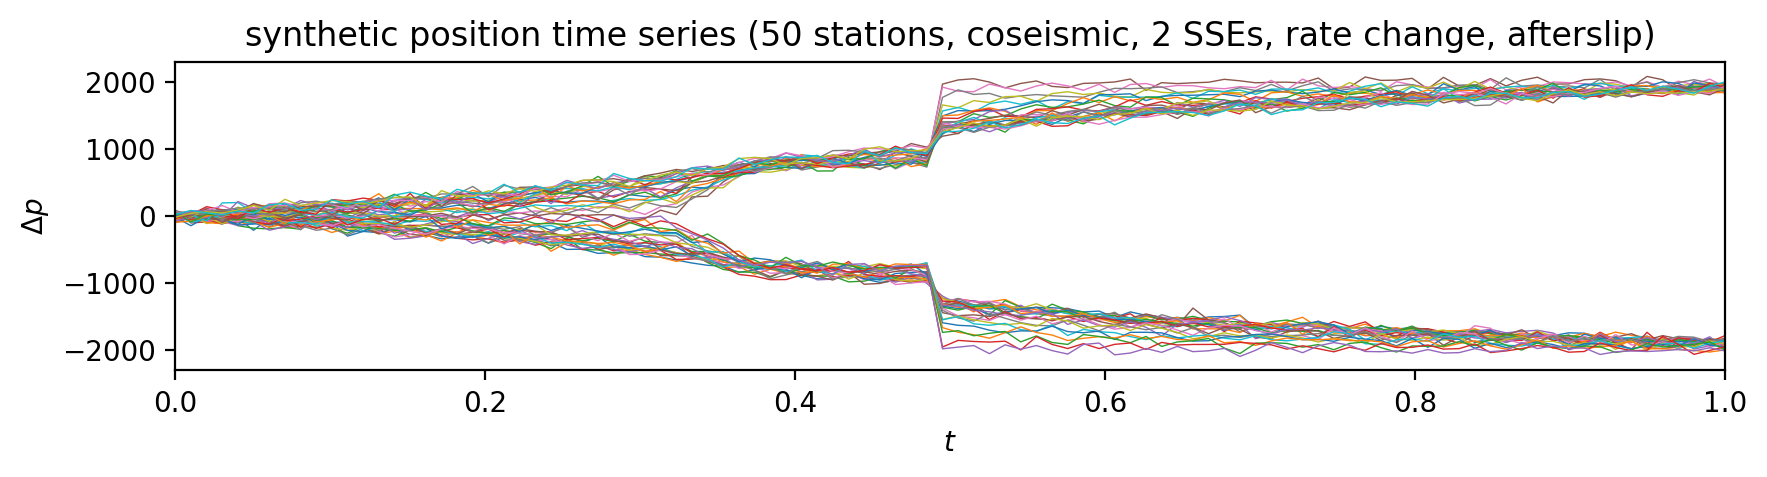

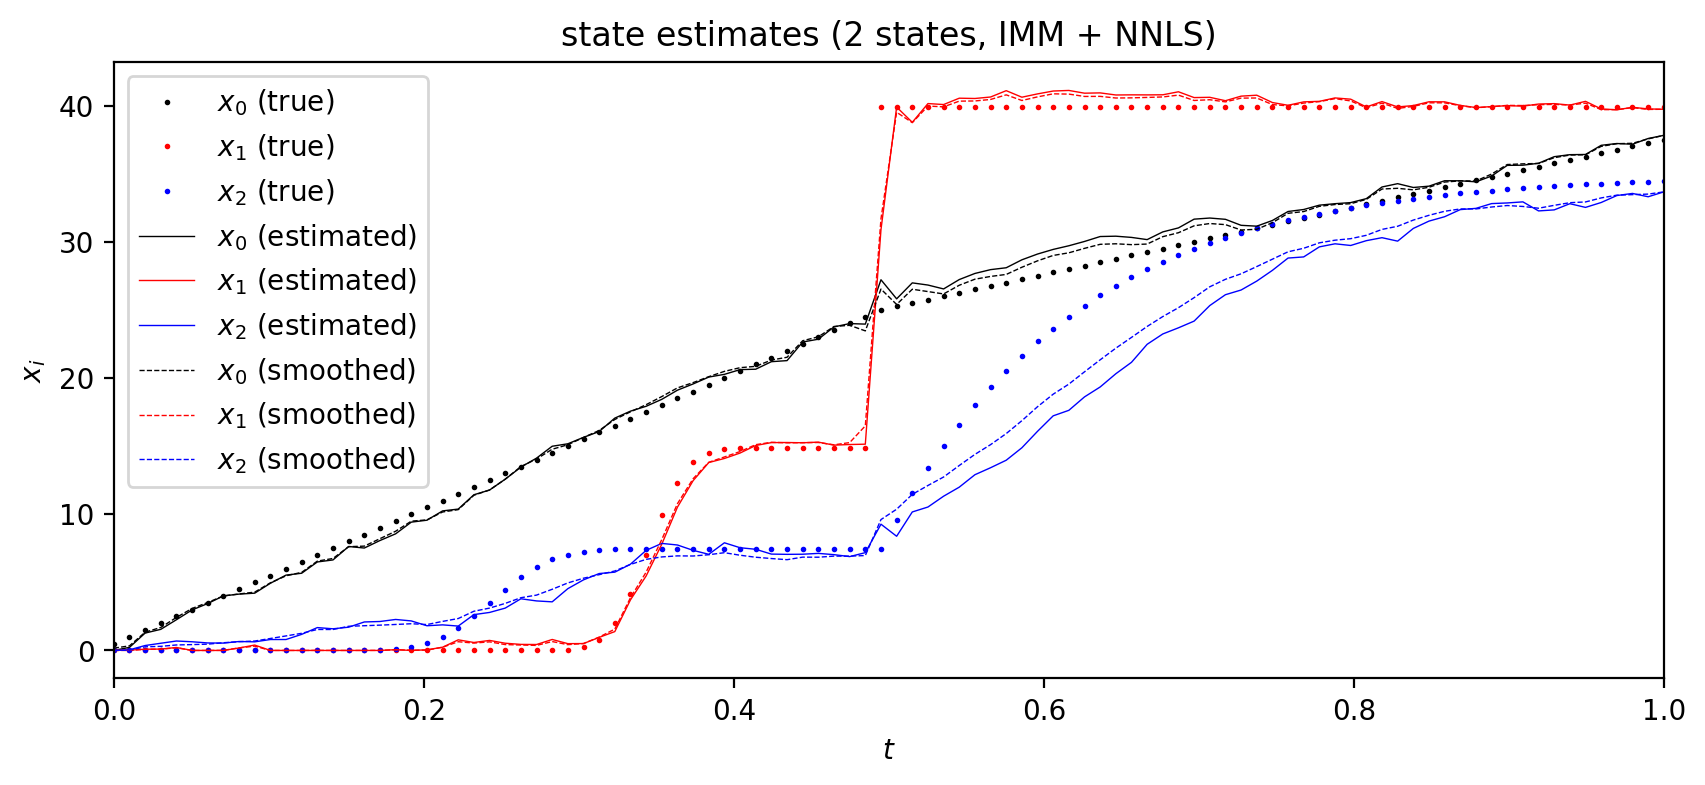

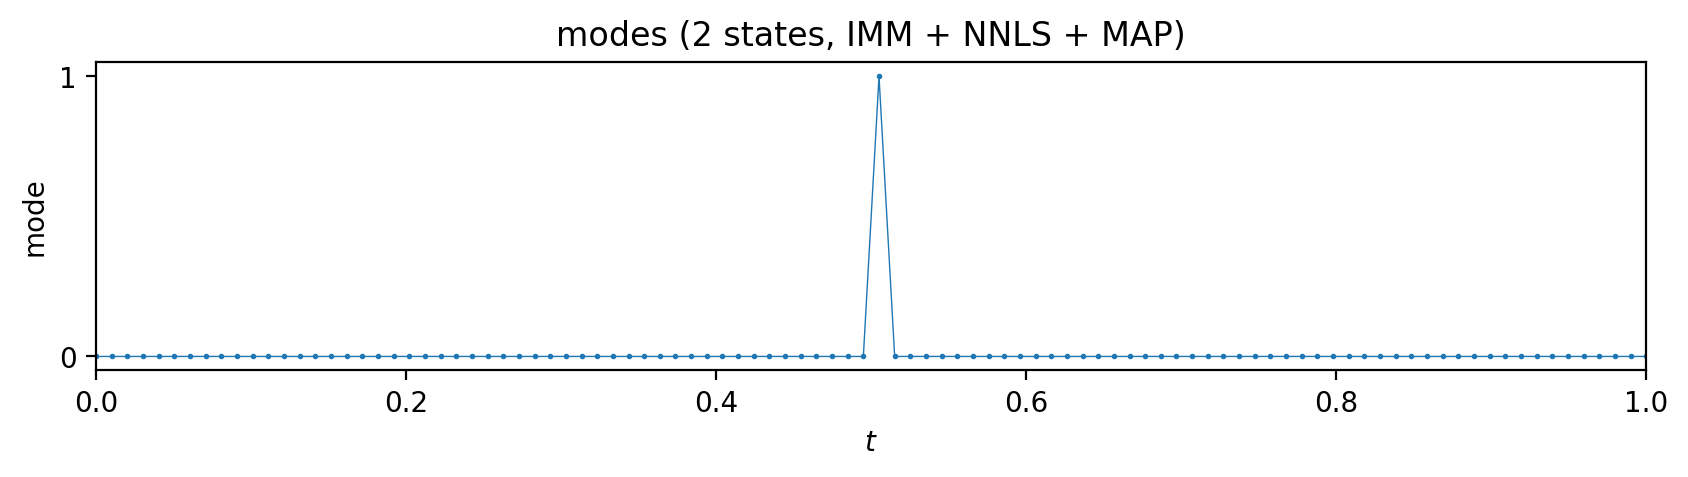

In [7]:
# Parameters for synthetic data
time_steps = 100
num_state_vars = 3  # Number of state variables
num_observations = 50  # Number of observation time series
observation_noise = 1.0

# Generate synthetic data
true_state = np.zeros((num_state_vars, time_steps))
observations = np.zeros((num_observations, time_steps))
true_modes = np.zeros(time_steps, dtype=int)
current_level = np.zeros(num_state_vars)
observations = np.copy(P_noise)

# MAP Algorithm with NNLS Setup
num_models = 2
transition_matrix = np.array([[0.9, 0.1], [0.1, 0.9]])
model_variances = [0.5, 5.0]  # Linear and jump variances

# Initialization
state_estimates = np.zeros((num_models, num_state_vars, time_steps))
covariances = np.zeros((num_models, num_state_vars, num_state_vars, time_steps))
mode_probabilities = np.zeros((num_models, time_steps))
mixed_estimates = np.zeros((num_state_vars, time_steps))
smoothed_estimates = np.zeros((num_state_vars, time_steps))
mode_sequence = np.zeros(time_steps, dtype=int)

# Initial values
mode_probabilities[:, 0] = 1 / num_models
for i in range(num_models):
    covariances[i, :, :, 0] = np.eye(num_state_vars) * model_variances[i]

# Forward Pass (Filtering)
for t in range(1, time_steps):
    likelihoods = np.zeros(num_models)
    log_likelihoods = np.zeros(num_models)

    for i in range(num_models):
        # Predict step
        if t == 1:
            mixed_state = np.zeros(num_state_vars)
            mixed_covariance = np.eye(num_state_vars) * model_variances[i]
        else:
            mixed_state = state_estimates[i, :, t - 1]
            mixed_covariance = (
                covariances[i, :, :, t - 1]
                + np.eye(num_state_vars) * model_variances[i]
            )

        # Update step
        innovation = observations[:, t] - H @ mixed_state
        innovation_covariance = (
            H @ mixed_covariance @ H.T + np.eye(num_observations) * observation_noise
        )

        # Regularize innovation covariance to avoid singularity
        innovation_covariance += np.eye(num_observations) * 1e-6

        kalman_gain = mixed_covariance @ H.T @ np.linalg.inv(innovation_covariance)

        # Apply Non-Negative Least Squares (NNLS) constraint
        unconstrained_estimate = mixed_state + kalman_gain @ innovation
        unconstrained_estimate = np.nan_to_num(
            unconstrained_estimate
        )  # Ensure no NaNs or Infs
        nnls_solution, _ = nnls(np.eye(num_state_vars), unconstrained_estimate)

        state_estimates[i, :, t] = nnls_solution
        covariances[i, :, :, t] = (
            np.eye(num_state_vars) - kalman_gain @ H
        ) @ mixed_covariance

        likelihoods[i] = norm.pdf(
            innovation, 0, np.sqrt(np.diag(innovation_covariance))
        ).prod()

        # Log likelihood
        log_likelihoods[i] = (
            -0.5 * np.log(np.linalg.det(innovation_covariance))
            - 0.5 * innovation.T @ innovation_covariance.T @ innovation
        )

    # Print likelihoods and log-likelihoods
    print(" ")
    print(f"{t=}")

    # Update mode probabilities using MAP
    transition_probs = transition_matrix[mode_sequence[t - 1]]
    posterior = likelihoods * transition_probs
    current_mode = np.argmax(
        posterior
    )  # Select the mode with maximum a posteriori probability
    # print(f"{likelihoods=}")
    # print(f"{posterior=}")
    # print(f"likelihoods, {np.argmax(posterior)=}")

    # BUG: The correct mode is not being selected
    posterior_log = log_likelihoods + np.log(transition_probs)
    current_mode_log = np.argmax(
        posterior_log
    )  # Select the mode with maximum a posteriori probability
    # print(" ")
    # print(f"{log_likelihoods=}")
    # print(f"{posterior_log=}")
    # print(f"log-likelihoods, {np.argmax(posterior_log)=}")

    print("likelihood")
    print(f"{likelihoods=}, {ltgt(likelihoods)}")
    print(f"{transition_probs=}, {ltgt(transition_probs)}")
    posterior = likelihoods * transition_probs
    print(f"{posterior=}, {ltgt(posterior)}")
    print(" ")
    print("log-likelihood")
    print(f"{log_likelihoods=}, {ltgt(log_likelihoods)}")
    print(f"{transition_probs=}, {ltgt(transition_probs)}")
    posterior_log = log_likelihoods + np.log(transition_probs)
    print(f"{posterior_log=}, {ltgt(posterior_log)}")
    print(" ")
    print("Compare selected index")
    print(f"{np.argmax(posterior)=}, {np.argmax(posterior_log)=}")

    current_mode = np.argmax(
        posterior_log
    )  # Select the mode with maximum a posteriori probability
    mode_sequence[t] = current_mode

    # Use the MAP mode's estimate for the mixed estimate
    mixed_estimates[:, t] = state_estimates[current_mode, :, t]

# Trying smoothing again
smoothed_estimates[:, -1] = mixed_estimates[
    :, -1
]  # Initialize with final filtered estimate
for t in range(time_steps - 2, -1, -1):
    for i in range(num_models):
        # Smoothing gain
        smoothing_gain = covariances[i, :, :, t] @ np.linalg.inv(
            covariances[i, :, :, t] + np.eye(num_state_vars) * model_variances[i]
        )

        # Smoothed estimate
        smoothed_estimates[:, t] = mixed_estimates[:, t] + smoothing_gain @ (
            smoothed_estimates[:, t + 1] - mixed_estimates[:, t]
        )

        # Apply NNLS constraint to smoothed estimate
        smoothed_estimates[:, t] = np.nan_to_num(smoothed_estimates[:, t])
        nnls_solution, _ = nnls(np.eye(num_state_vars), smoothed_estimates[:, t])
        smoothed_estimates[:, t] = nnls_solution

# Plot results
linewidth = 0.5
markersize = 2.0

plt.figure(figsize=(10, 2))
for i in range(50):
    plt.plot(
        time_vec,
        100 * P_noise[i, :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
# plt.ylim([-25, 25])
plt.title(
    "synthetic position time series (50 stations, coseismic, 2 SSEs, rate change, afterslip)"
)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    time_vec, x0, ".k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x1, ".r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x2, ".b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize
)

plt.plot(
    time_vec,
    mixed_estimates[0, :] / dt / 100,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[1, :] / dt / 100,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[2, :] / dt / 100,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.plot(
    time_vec,
    smoothed_estimates[0, :] / dt / 100,
    "--k",
    label="$x_0$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[1, :] / dt / 100,
    "--r",
    label="$x_1$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[2, :] / dt / 100,
    "--b",
    label="$x_2$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state estimates (2 states, IMM + NNLS)")
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(
    time_vec,
    mode_sequence,
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("mode")
plt.xlim([0, 1])
plt.yticks(range(2))
plt.title("modes (2 states, IMM + NNLS + MAP)")
plt.show()

# IMM with MAP and smoother (5 states)

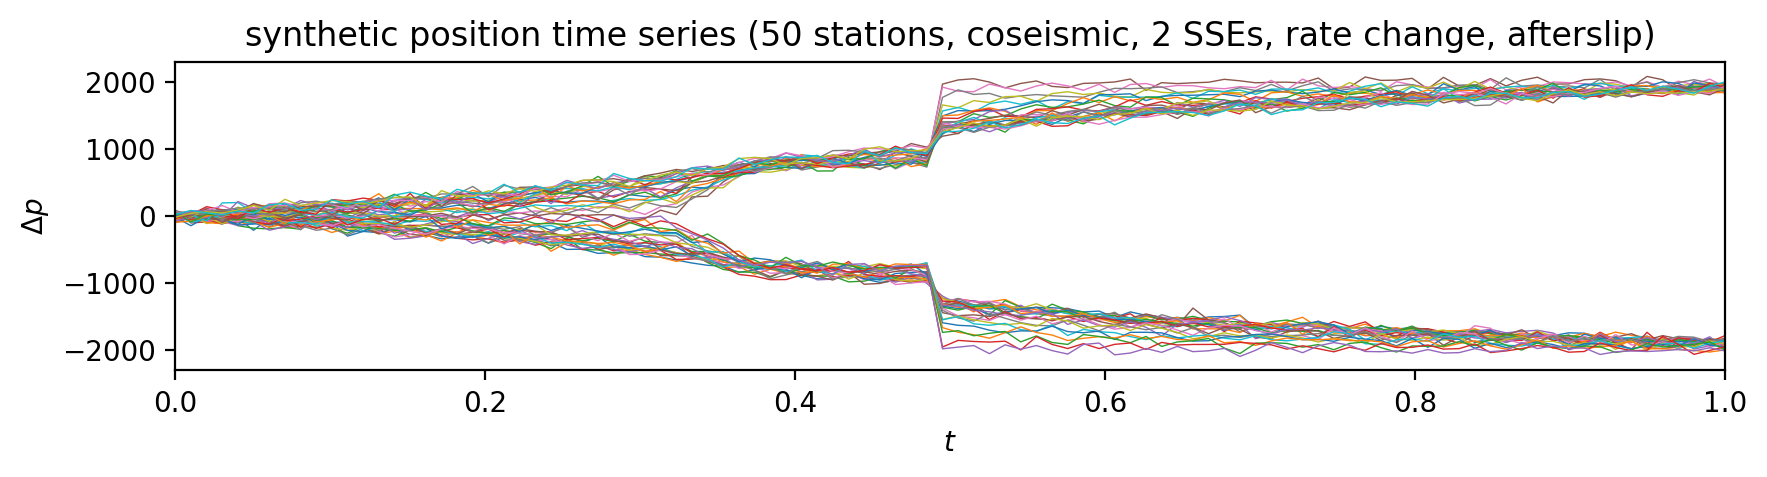

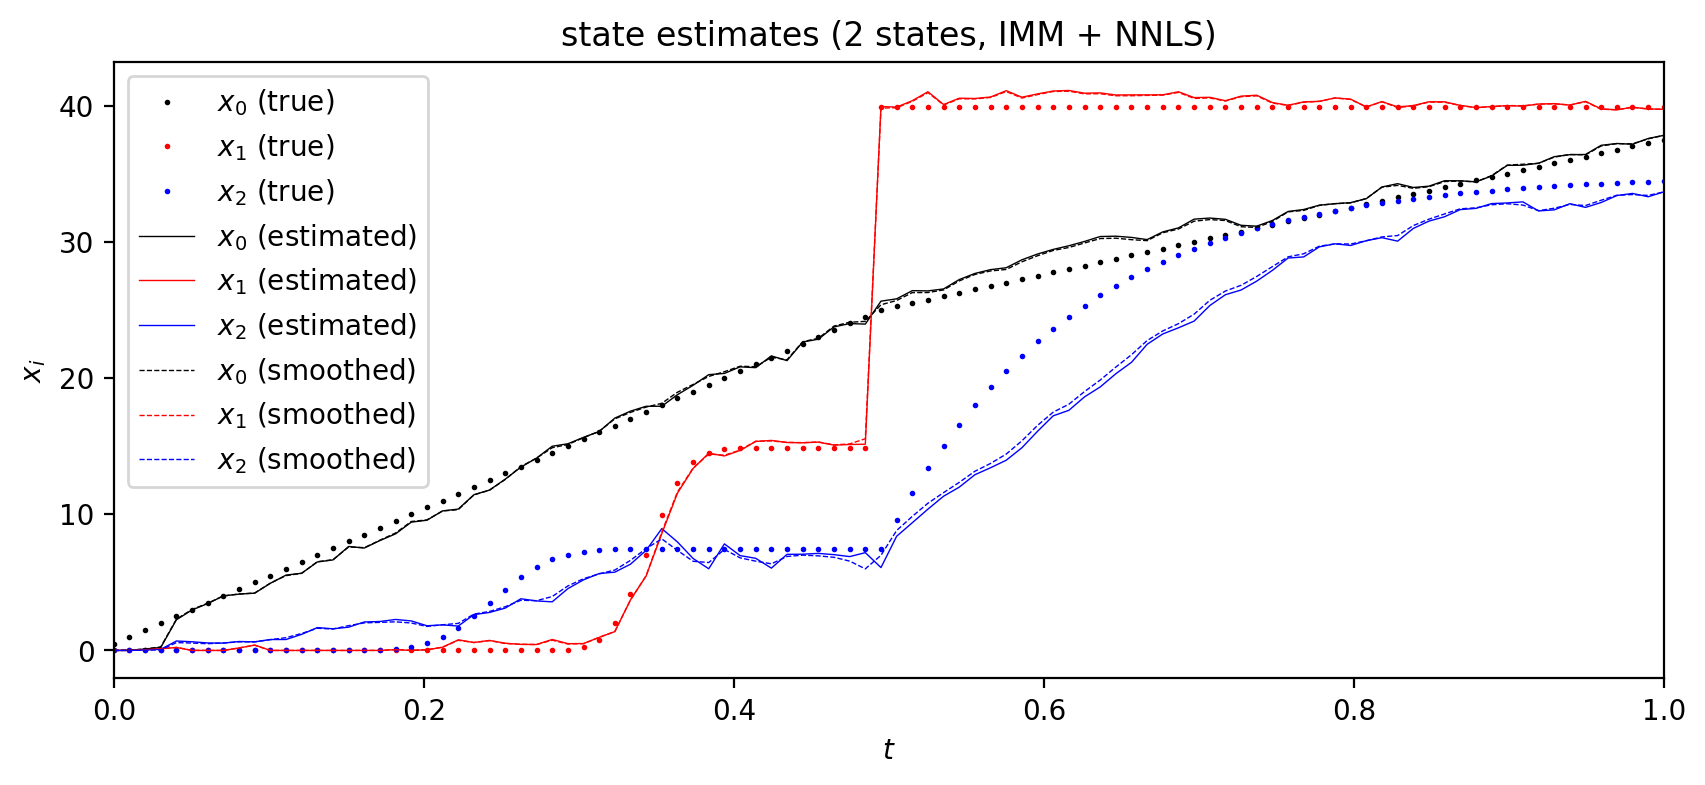

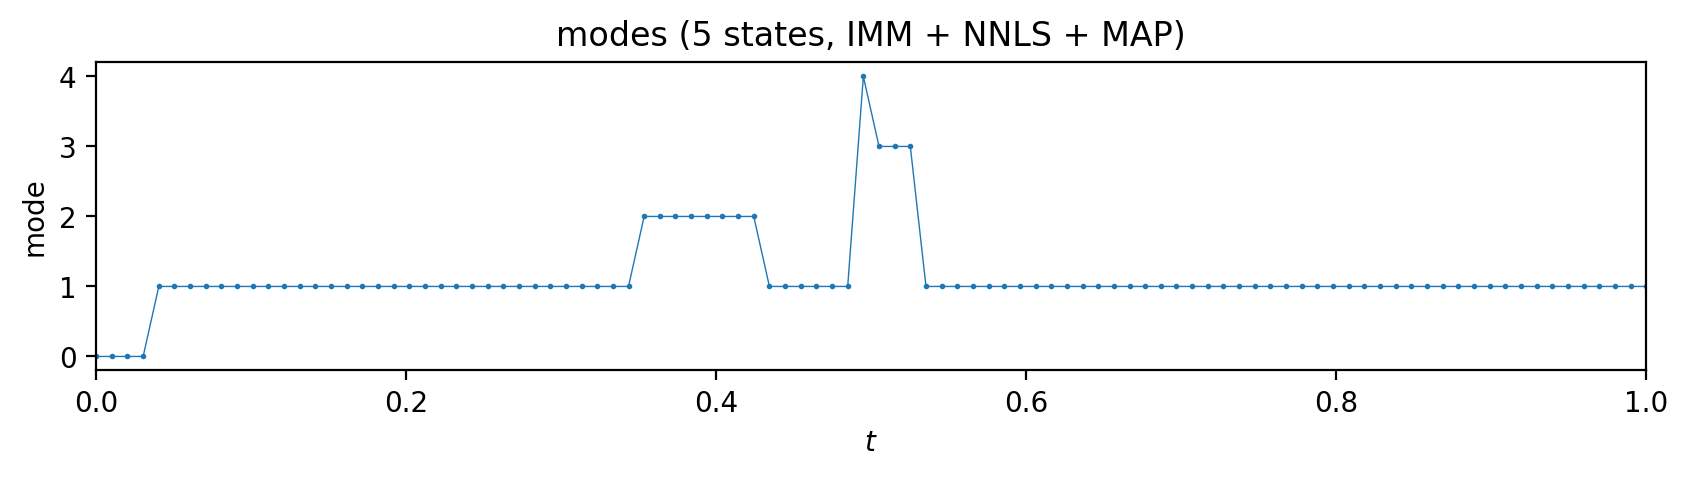

In [8]:
# Parameters for synthetic data
time_steps = 100
num_state_vars = 3  # Number of state variables
num_observations = 50  # Number of observation time series
observation_noise = 1.0

# Generate synthetic data
true_state = np.zeros((num_state_vars, time_steps))
observations = np.zeros((num_observations, time_steps))
true_modes = np.zeros(time_steps, dtype=int)
current_level = np.zeros(num_state_vars)
observations = np.copy(P_noise)

# MAP parameters
num_models = 5
transition_matrix = np.array(
    [
        [0.90, 0.02, 0.02, 0.02, 0.02],
        [0.02, 0.90, 0.02, 0.02, 0.02],
        [0.02, 0.02, 0.90, 0.02, 0.02],
        [0.02, 0.02, 0.02, 0.90, 0.02],
        [0.02, 0.02, 0.02, 0.02, 0.90],
    ]
)
model_variances = [0.01, 0.5, 2.5, 5.0, 50.0]
# model_variances = [0.01, 0.5, 2.5, 5.0, 50.0]
# model_variances = np.logspace(-1.0, 1.0, 5)  # Logarithmic variance distribution

# Initialization
state_estimates = np.zeros((num_models, num_state_vars, time_steps))
covariances = np.zeros((num_models, num_state_vars, num_state_vars, time_steps))
mode_probabilities = np.zeros((num_models, time_steps))
mixed_estimates = np.zeros((num_state_vars, time_steps))
smoothed_estimates = np.zeros((num_state_vars, time_steps))
mode_sequence = np.zeros(time_steps, dtype=int)

# Initial values
mode_probabilities[:, 0] = 1 / num_models
for i in range(num_models):
    covariances[i, :, :, 0] = np.eye(num_state_vars) * model_variances[i]

# Forward Pass (Filtering)
for t in range(1, time_steps):
    likelihoods = np.zeros(num_models)
    for i in range(num_models):
        # Predict step
        if t == 1:
            mixed_state = np.zeros(num_state_vars)
            mixed_covariance = np.eye(num_state_vars) * model_variances[i]
        else:
            mixed_state = state_estimates[i, :, t - 1]
            mixed_covariance = (
                covariances[i, :, :, t - 1]
                + np.eye(num_state_vars) * model_variances[i]
            )

        # Update step
        innovation = observations[:, t] - H @ mixed_state
        innovation_covariance = (
            H @ mixed_covariance @ H.T + np.eye(num_observations) * observation_noise
        )

        # Regularize innovation covariance to avoid singularity
        innovation_covariance += np.eye(num_observations) * 1e-6

        kalman_gain = mixed_covariance @ H.T @ np.linalg.inv(innovation_covariance)

        # Apply Non-Negative Least Squares (NNLS) constraint
        unconstrained_estimate = mixed_state + kalman_gain @ innovation
        unconstrained_estimate = np.nan_to_num(
            unconstrained_estimate
        )  # Ensure no NaNs or Infs
        nnls_solution, _ = nnls(np.eye(num_state_vars), unconstrained_estimate)

        state_estimates[i, :, t] = nnls_solution
        covariances[i, :, :, t] = (
            np.eye(num_state_vars) - kalman_gain @ H
        ) @ mixed_covariance

        likelihoods[i] = norm.pdf(
            innovation, 0, np.sqrt(np.diag(innovation_covariance))
        ).prod()

    # Update mode probabilities using MAP
    transition_probs = transition_matrix[mode_sequence[t - 1]]
    posterior = likelihoods * transition_probs
    current_mode = np.argmax(
        posterior
    )  # Select the mode with maximum a posteriori probability
    mode_sequence[t] = current_mode

    # Use the MAP mode's estimate for the mixed estimate
    mixed_estimates[:, t] = state_estimates[current_mode, :, t]

map_mode_probabilities = np.copy(mode_probabilities)

# Trying smoothing again
smoothed_estimates[:, -1] = mixed_estimates[
    :, -1
]  # Initialize with final filtered estimate
for t in range(time_steps - 2, -1, -1):
    for i in range(num_models):
        # Smoothing gain
        smoothing_gain = covariances[i, :, :, t] @ np.linalg.inv(
            covariances[i, :, :, t] + np.eye(num_state_vars) * model_variances[i]
        )

        # Smoothed estimate
        smoothed_estimates[:, t] = mixed_estimates[:, t] + smoothing_gain @ (
            smoothed_estimates[:, t + 1] - mixed_estimates[:, t]
        )

        # Apply NNLS constraint to smoothed estimate
        smoothed_estimates[:, t] = np.nan_to_num(smoothed_estimates[:, t])
        nnls_solution, _ = nnls(np.eye(num_state_vars), smoothed_estimates[:, t])
        smoothed_estimates[:, t] = nnls_solution

# Plot results
linewidth = 0.5
markersize = 2.0

plt.figure(figsize=(10, 2))
for i in range(50):
    plt.plot(
        time_vec,
        100 * P_noise[i, :],
        "-",
        linewidth=linewidth,
        markersize=markersize,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
# plt.ylim([-25, 25])
plt.title(
    "synthetic position time series (50 stations, coseismic, 2 SSEs, rate change, afterslip)"
)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    time_vec, x0, ".k", label="$x_0$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x1, ".r", label="$x_1$ (true)", linewidth=linewidth, markersize=markersize
)
plt.plot(
    time_vec, x2, ".b", label="$x_2$ (true)", linewidth=linewidth, markersize=markersize
)

plt.plot(
    time_vec,
    mixed_estimates[0, :] / dt / 100,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[1, :] / dt / 100,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    mixed_estimates[2, :] / dt / 100,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.plot(
    time_vec,
    smoothed_estimates[0, :] / dt / 100,
    "--k",
    label="$x_0$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[1, :] / dt / 100,
    "--r",
    label="$x_1$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    smoothed_estimates[2, :] / dt / 100,
    "--b",
    label="$x_2$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state estimates (2 states, IMM + NNLS)")
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(
    time_vec,
    mode_sequence,
    ".-",
    linewidth=linewidth,
    markersize=markersize,
)
plt.xlabel("$t$")
plt.ylabel("mode")
plt.xlim([0, 1])
plt.yticks(range(num_models))
plt.title(f"modes ({num_models} states, IMM + NNLS + MAP)")
plt.show()

# Compare MCMC modes with MAP modes

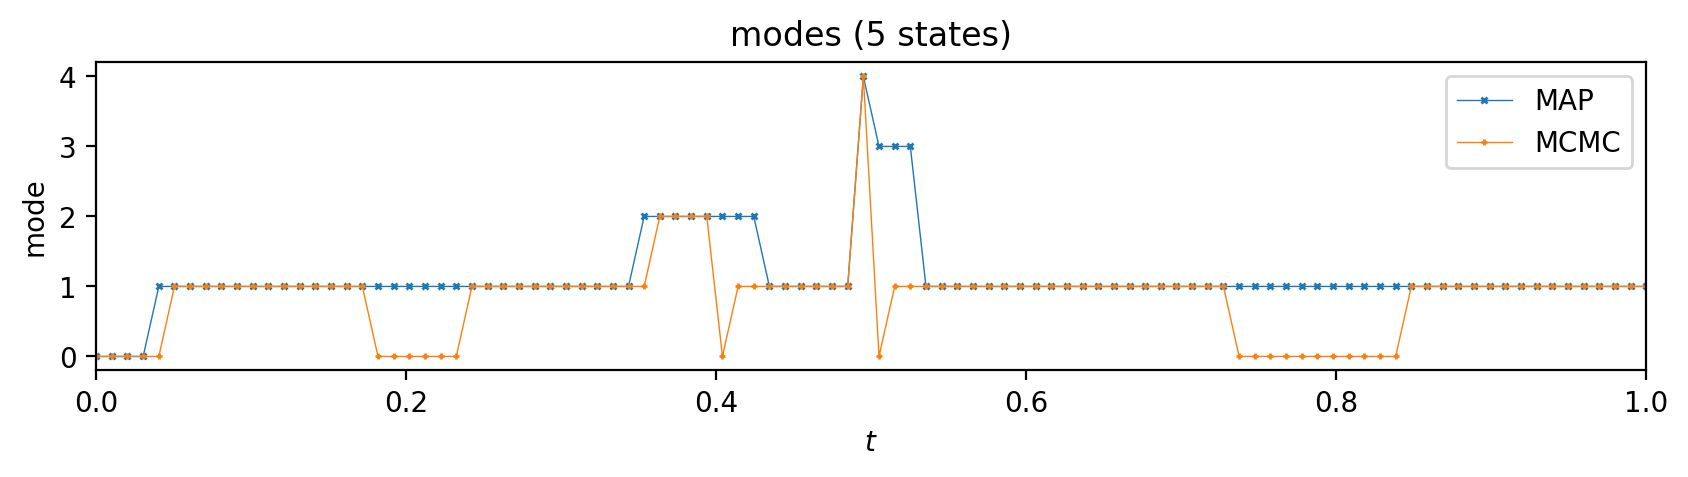

In [9]:
plt.figure(figsize=(10, 2))
plt.plot(
    time_vec,
    mode_sequence,
    "x-",
    linewidth=linewidth,
    markersize=markersize,
    label="MAP",
)

plt.plot(
    time_vec,
    np.argmax(mcmc_mode_probabilities, axis=0),
    "+-",
    linewidth=linewidth,
    markersize=markersize,
    label="MCMC",
)

plt.xlabel("$t$")
plt.ylabel("mode")
plt.xlim([0, 1])
plt.legend()
plt.yticks(range(num_models))
plt.title(f"modes ({num_models} states)")
plt.show()

# Global Tikhonov smoother
- Coseismic jumps are removed
- I think I just built a pretty complicated post-processing step that may still break constraints.  Not sure?

In [10]:
def nnls_per_timestep(A, b_list):
    T = len(b_list)
    n = A.shape[1]
    x_est = np.zeros((T, n))

    for t in range(T):
        x_est[t], _ = nnls(A, b_list[t])

    return x_est


def smooth_nnls(A, b_list, alpha=1.0, max_iter=200, lr=1e-2):
    """
    Solve for x(t) by minimizing:

    Sum ||A x(t) - b(t)||^2 + alpha * Sum ||x(t+1) - x(t)||^2

    With the constraint: subject to x(t) >= 0 at all t.
    """
    nt = len(b_list)

    # Initialize x_est by solving NNLS at each time step individually.
    x_est = nnls_per_timestep(A, b_list)

    for i in range(max_iter):
        # Gradient storage
        grad = np.zeros_like(x_est)

        # Data fit gradient: ||A x(t) - b(t)||^2
        # - Derivative wrt x(t): 2 A^T (A x(t) - b(t))
        for t in range(nt):
            residual = A.dot(x_est[t]) - b_list[t]
            grad[t] += 2.0 * A.T.dot(residual)

        # Time smoothness gradient: alpha * Sum ||x(t+1) - x(t)||^2
        # For ||x_{t+1} - x_t||^2:
        # - Derivative wrt x(t): 2 (x(t) - x(t+1))
        # - Derivative wrt x(t+1): 2 (x(t+1) - x(t))
        for t in range(nt - 1):
            diff = x_est[t] - x_est[t + 1]  # x(t) - x(t+1)
            grad[t] += alpha * 2.0 * diff
            grad[t + 1] -= alpha * 2.0 * diff

        # Gradient step with learning rate
        x_est = x_est - lr * grad

        # Project onto x >= 0
        np.clip(x_est, 0, None, out=x_est)

        if i % 50 == 0 or i == max_iter - 1:
            # Compute current objective
            obj_data = 0.0
            obj_smooth = 0.0
            for t in range(nt):
                res = A.dot(x_est[t]) - b_list[t]
                obj_data += np.sum(res**2)
            for t2 in range(nt - 1):
                diff = x_est[t2 + 1] - x_est[t2]
                obj_smooth += np.sum(diff**2)
            obj = obj_data + alpha * obj_smooth
            print(f"{i=:4d}: {obj=:.4f}, {obj_data=:.4f}, {obj_smooth=:.4f}")

    return x_est


# Time smoothing weight
alpha = 5.0

# Maximum number of iterations
max_iter = 300

# Learning rate
lr = 1e-3

# Package observation into a list of arrays for each time step
b_list = [_ for _ in P_noise_noco.T]

# Solve
x_tik = smooth_nnls(A, b_list, alpha=alpha, max_iter=max_iter, lr=lr)

i=   0: obj=11422.3851, obj_data=2682.1048, obj_smooth=1748.0561
i=  50: obj=4093.7812, obj_data=2709.1908, obj_smooth=276.9181
i= 100: obj=3479.9822, obj_data=2723.0946, obj_smooth=151.3775
i= 150: obj=3340.0557, obj_data=2729.7180, obj_smooth=122.0675
i= 200: obj=3283.2155, obj_data=2733.6998, obj_smooth=109.9031
i= 250: obj=3251.6710, obj_data=2736.4462, obj_smooth=103.0450
i= 299: obj=3231.2228, obj_data=2738.4454, obj_smooth=98.5555


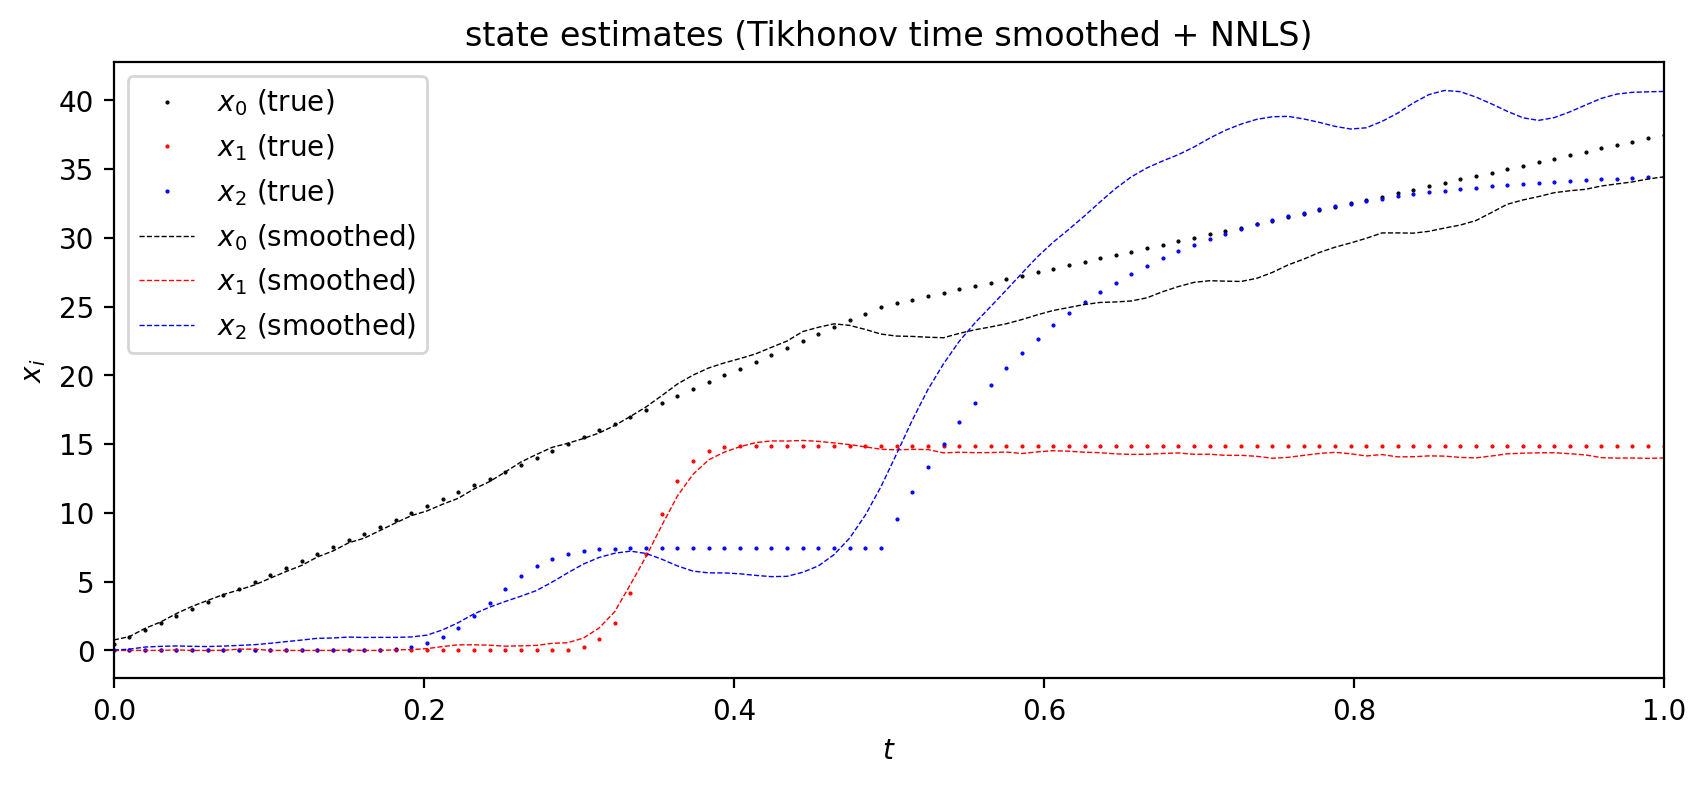

In [13]:
linewidth = 0.5
markersize = 1.0

plt.figure(figsize=(10, 4))
plt.plot(
    time_vec,
    x0_noco,
    ".k",
    label="$x_0$ (true)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x1_noco,
    ".r",
    label="$x_1$ (true)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x2_noco,
    ".b",
    label="$x_2$ (true)",
    linewidth=linewidth,
    markersize=markersize,
)

# plt.plot(
#     time_vec,
#     mixed_estimates[0, :] / dt / 100,
#     "-k",
#     label="$x_0$ (estimated)",
#     linewidth=linewidth,
#     markersize=markersize,
# )
# plt.plot(
#     time_vec,
#     mixed_estimates[1, :] / dt / 100,
#     "-r",
#     label="$x_1$ (estimated)",
#     linewidth=linewidth,
#     markersize=markersize,
# )
# plt.plot(
#     time_vec,
#     mixed_estimates[2, :] / dt / 100,
#     "-b",
#     label="$x_2$ (estimated)",
#     linewidth=linewidth,
#     markersize=markersize,
# )

plt.plot(
    time_vec,
    x_tik[:, 0] / dt / 100,
    "--k",
    label="$x_0$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x_tik[:, 1] / dt / 100,
    "--r",
    label="$x_1$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)
plt.plot(
    time_vec,
    x_tik[:, 2] / dt / 100,
    "--b",
    label="$x_2$ (smoothed)",
    linewidth=linewidth,
    markersize=markersize,
)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state estimates (Tikhonov time smoothed + NNLS)")
plt.show()